In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
save_path = "/content/drive/MyDrive/Diabetic_Retnopathy"
os.makedirs(save_path, exist_ok=True)

Mounted at /content/drive


In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!pip install -q kaggle

!kaggle datasets download -d ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy

!unzip -q /content/eyepacs-aptos-messidor-diabetic-retinopathy.zip "augmented_resized_V2/*" -d /content/

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy
License(s): other
100% 20.5G/20.5G [22:33<00:00, 16.2MB/s]



In [ ]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import mixed_precision

from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [ ]:
mixed_precision.set_global_policy('mixed_float16')

print("Mixed precision:", mixed_precision.global_policy())

base = "/content/augmented_resized_V2"

train_path = base + "/train"
val_path   = base + "/val"
test_path  = base + "/test"

Mixed precision: <DTypePolicy "mixed_float16">


In [ ]:
IMG_SIZE = 256
BATCH = 256
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    label_mode='categorical'
)

val_data = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    label_mode='categorical'
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    label_mode='categorical',
    shuffle=False
)

Found 115241 files belonging to 5 classes.
Found 14227 files belonging to 5 classes.
Found 14201 files belonging to 5 classes.


In [ ]:
train_data = train_data.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
val_data   = val_data.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
test_data  = test_data.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)

train_data = train_data.prefetch(AUTOTUNE)
val_data   = val_data.prefetch(AUTOTUNE)
test_data  = test_data.prefetch(AUTOTUNE)

print("Pipeline ready")

Pipeline ready


In [ ]:
def map_to_4class(x, y):
    y = tf.argmax(y, axis=1)
    y = tf.cast(y, tf.int32)   # 🔥 FIX

    y = tf.where(y >= 3, 3, y)

    y = tf.one_hot(y, depth=4)
    return x, y
train_4 = train_data.map(map_to_4class)
val_4   = val_data.map(map_to_4class)
test_4  = test_data.map(map_to_4class)

In [ ]:
def map_to_3class(x, y):
    y = tf.argmax(y, axis=1)
    y = tf.cast(y, tf.int32)   # 🔥 FIX

    y = tf.where(y == 0, 0,
         tf.where(y <= 2, 1, 2))

    y = tf.one_hot(y, depth=3)
    return x, y

train_3 = train_data.map(map_to_3class)
val_3   = val_data.map(map_to_3class)
test_3  = test_data.map(map_to_3class)

In [ ]:
def build_model(num_classes):
    base_model = EfficientNetB3(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(base_model.input, output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

callbacks = [
    ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

In [ ]:
model_4 = build_model(4)

history_stock_4 = model_4.fit(
    train_4,
    validation_data=val_4,
    epochs=5,
    callbacks=callbacks
)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 353s 477ms/step - accuracy: 0.6360 - loss: 0.9122 - val_accuracy: 0.7131 - val_loss: 0.7516 - learning_rate: 0.0010
Epoch 2/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.6723 - loss: 0.8278 - val_accuracy: 0.7240 - val_loss: 0.7245 - learning_rate: 0.0010
Epoch 3/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.6814 - loss: 0.8054 - val_accuracy: 0.7288 - val_loss: 0.7069 - learning_rate: 0.0010
Epoch 4/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.6899 - loss: 0.7858 - val_accuracy: 0.7406 - val_loss: 0.6842 - learning_rate: 0.0010
Epoch 5/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 40s 88ms/step - accuracy: 0.6942 - loss: 0.7733 - val_accuracy: 0.7407 - val_loss: 0.6859 - learning_rate: 0.0010
Epoch 6/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.6997 - loss: 0.7626 - val_accuracy: 0.7441 - val_loss: 0.6761 - learning_rate: 0.0010
Epoch 7/15
451/451 ━━━━

In [ ]:
# Unfreeze last 100 layers for the 4-class model
for layer in model_4.layers:
    layer.trainable = True

for layer in model_4.layers[:-100]:
    layer.trainable = False

# We use the exact same loss function and optimizer settings as the 5-class notebook
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model_4.compile(
    optimizer=tf.keras.optimizers.Adam(2e-5),
    loss=loss_fn,
    metrics=['accuracy']
)


In [ ]:
# Fine-tune the 4-class model
history_4 = model_4.fit(
    train_4,
    validation_data=val_4,
    epochs=15,
    callbacks=callbacks
)


In [ ]:
model_3 = build_model(3)

history_stock_3 = model_3.fit(
    train_3,
    validation_data=val_3,
    epochs=5,
    callbacks=callbacks
)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 341s 453ms/step - accuracy: 0.6882 - loss: 0.6852 - val_accuracy: 0.7471 - val_loss: 0.5831 - learning_rate: 0.0010
Epoch 2/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.7222 - loss: 0.6264 - val_accuracy: 0.7583 - val_loss: 0.5596 - learning_rate: 0.0010
Epoch 3/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.7339 - loss: 0.6043 - val_accuracy: 0.7639 - val_loss: 0.5442 - learning_rate: 0.0010
Epoch 4/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.7394 - loss: 0.5915 - val_accuracy: 0.7654 - val_loss: 0.5482 - learning_rate: 0.0010
Epoch 5/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.7457 - loss: 0.5823 - val_accuracy: 0.7723 - val_loss: 0.5328 - learning_rate: 0.0010
Epoch 6/15
451/451 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.7470 - loss: 0.5755 - val_accuracy: 0.7731 - val_loss: 0.5285 - learning_rate: 0.0010
Epoch 7/15
451/451 ━━━━

In [ ]:
# Unfreeze last 100 layers for the 3-class model
for layer in model_3.layers:
    layer.trainable = True

for layer in model_3.layers[:-100]:
    layer.trainable = False

model_3.compile(
    optimizer=tf.keras.optimizers.Adam(2e-5),
    loss=loss_fn,
    metrics=['accuracy']
)


In [ ]:
# Fine-tune the 3-class model
history_3 = model_3.fit(
    train_3,
    validation_data=val_3,
    epochs=15,
    callbacks=callbacks
)


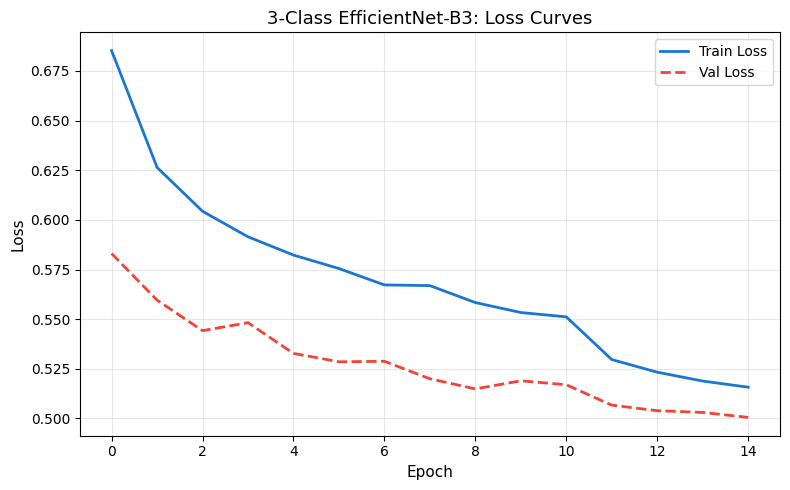

loss_curves.png saved!


In [ ]:
import matplotlib.pyplot as plt

# ── Loss Curves (3-Class) ──
plt.figure(figsize=(8, 5))
plt.plot(history_3.history['loss'],     label='Train Loss', linewidth=2, color='#1976D2')
plt.plot(history_3.history['val_loss'], label='Val Loss',   linewidth=2, color='#F44336', linestyle='--')
plt.title("3-Class EfficientNet-B3: Loss Curves", fontsize=13)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Loss", fontsize=11)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Diabetic_Retnopathy/loss_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("loss_curves.png saved!")

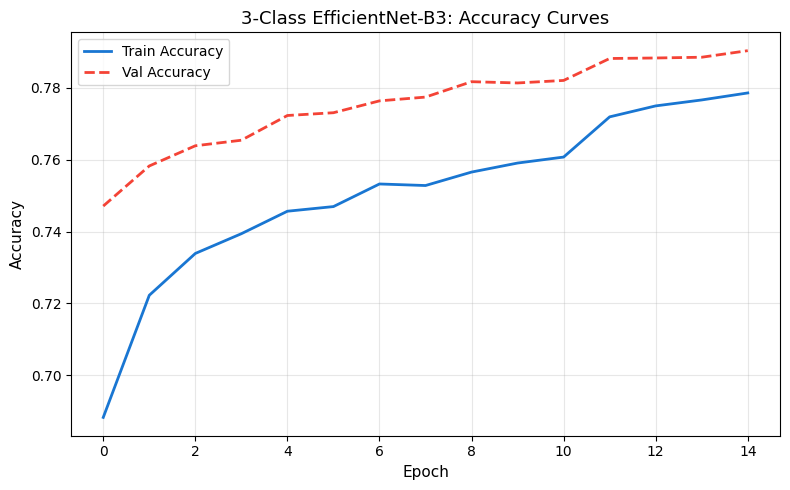

accuracy_curves.png saved!


In [ ]:
# ── Accuracy Curves (3-Class) ──
plt.figure(figsize=(8, 5))
plt.plot(history_3.history['accuracy'],     label='Train Accuracy', linewidth=2, color='#1976D2')
plt.plot(history_3.history['val_accuracy'], label='Val Accuracy',   linewidth=2, color='#F44336', linestyle='--')
plt.title("3-Class EfficientNet-B3: Accuracy Curves", fontsize=13)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Diabetic_Retnopathy/accuracy_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("accuracy_curves.png saved!")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def evaluate_model(model, dataset, name, save_name):

    # ── Evaluation ──
    loss, acc = model.evaluate(dataset)
    print(f"\n{name} Accuracy: {acc:.4f}")

    # ── Predictions ──
    preds  = model.predict(dataset)
    preds  = np.argmax(preds, axis=1)

    y_true = []
    for _, labels in dataset:
        y_true.append(labels.numpy())
    y_true = np.concatenate(y_true, axis=0)
    y_true = np.argmax(y_true, axis=1)

    # ── Metrics ──
    macro_f1      = f1_score(y_true, preds, average='macro')
    weighted_f1   = f1_score(y_true, preds, average='weighted')
    macro_recall  = recall_score(y_true, preds, average='macro')
    weighted_recall = recall_score(y_true, preds, average='weighted')

    print(f"Macro F1: {macro_f1:.4f} | Weighted F1: {weighted_f1:.4f}")
    print(f"Macro Recall: {macro_recall:.4f} | Weighted Recall: {weighted_recall:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, preds))

    cm = confusion_matrix(y_true, preds)

    # ── 1. Confusion Matrix — saved to Drive ──
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", annot_kws={"size": 16})
    plt.xlabel("Predicted Label", fontsize=11)
    plt.ylabel("True Label", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/Diabetic_Retnopathy/cm_{save_name}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"cm_{save_name}.png saved!")

    # ── 2. Normalised Confusion Matrix — saved to Drive ──
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", annot_kws={"size": 16})
    plt.xlabel("Predicted Label", fontsize=11)
    plt.ylabel("True Label", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/Diabetic_Retnopathy/cm_norm_{save_name}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"cm_norm_{save_name}.png saved!")

    return {"accuracy": acc, "macro_f1": macro_f1, "weighted_f1": weighted_f1,
            "macro_recall": macro_recall, "weighted_recall": weighted_recall}

56/56 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.6800 - loss: 0.9325

4-Class Model Accuracy: 0.6800
56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 301ms/step
Macro F1: 0.5481 | Weighted F1: 0.6430
Macro Recall: 0.5586 | Weighted Recall: 0.6800

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.96      0.86      6896
           1       0.39      0.31      0.35      1862
           2       0.40      0.20      0.27      2999
           3       0.68      0.76      0.72      2444

    accuracy                           0.68     14201
   macro avg       0.56      0.56      0.55     14201
weighted avg       0.63      0.68      0.64     14201



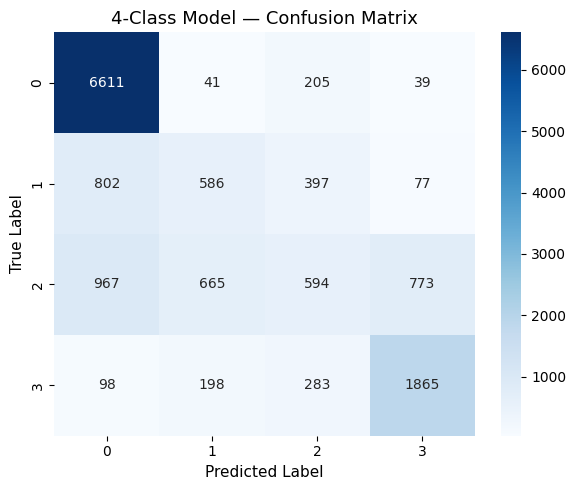

cm_4class.png saved!


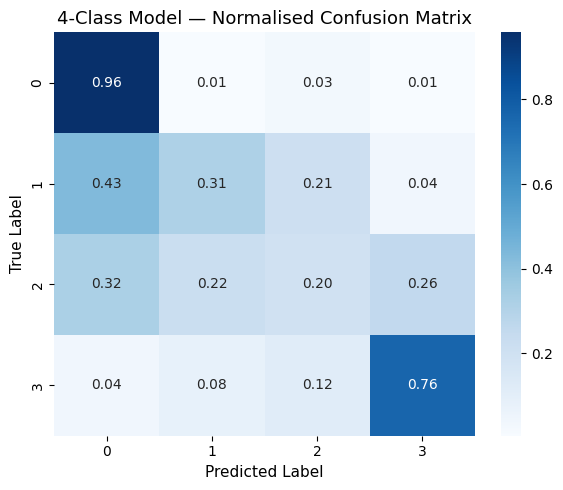

cm_norm_4class.png saved!
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 275ms/step - accuracy: 0.7671 - loss: 0.5402

3-Class Model Accuracy: 0.7671
56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 312ms/step
Macro F1: 0.7365 | Weighted F1: 0.7554
Macro Recall: 0.7387 | Weighted Recall: 0.7671

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.94      0.86      6896
           1       0.74      0.53      0.62      4861
           2       0.72      0.74      0.73      2444

    accuracy                           0.77     14201
   macro avg       0.75      0.74      0.74     14201
weighted avg       0.76      0.77      0.76     14201



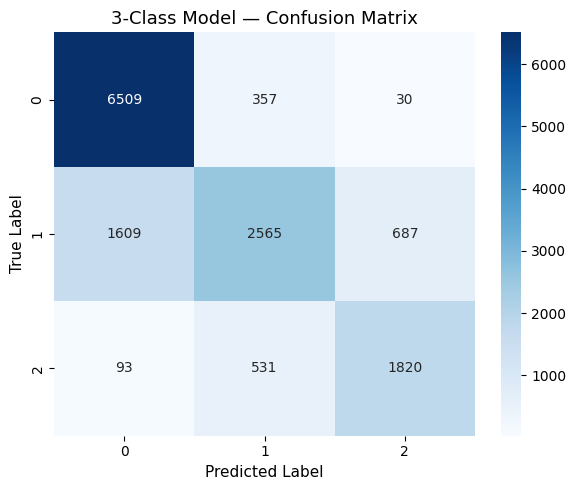

cm_3class.png saved!


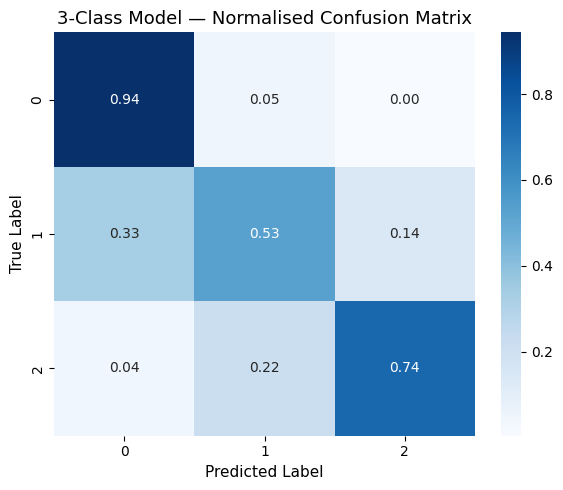

cm_norm_3class.png saved!


In [ ]:
 results_4 = evaluate_model(model_4, test_4, "4-Class Model", save_name="4class")
results_3 = evaluate_model(model_3, test_3, "3-Class Model", save_name="3class")

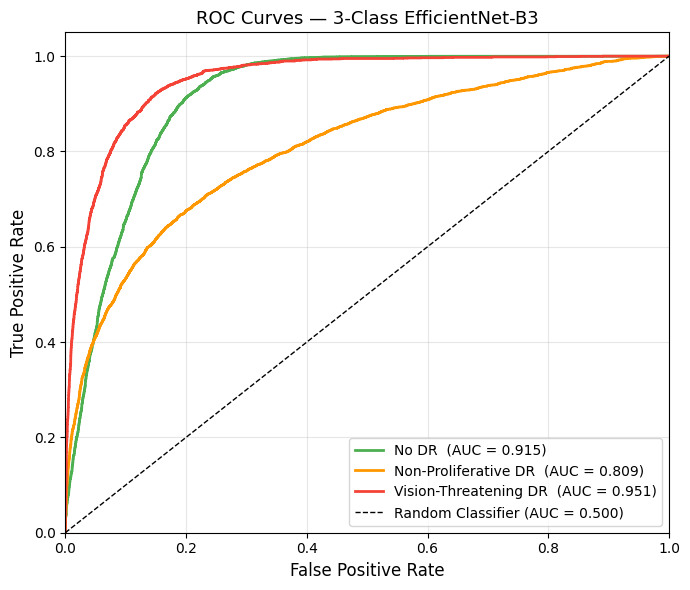

Saved to Drive!


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# ── Step 1: Get true labels and predicted probabilities ──
y_true_roc = []
y_prob_roc = []

for images, labels in test_3:
    y_true_roc.append(labels.numpy())
    y_prob_roc.append(model_3.predict(images, verbose=0))

y_true_roc = np.concatenate(y_true_roc, axis=0)   # shape: (N, 3) one-hot
y_prob_roc = np.concatenate(y_prob_roc, axis=0)   # shape: (N, 3) probabilities

# ── Step 2: Convert one-hot to integer labels ──
y_true_int = np.argmax(y_true_roc, axis=1)

# ── Step 3: Binarize for one-vs-rest ROC ──
y_true_bin = label_binarize(y_true_int, classes=[0, 1, 2])  # shape: (N, 3)

# ── Step 4: Compute ROC curve and AUC per class ──
class_names = ["No DR", "Non-Proliferative DR", "Vision-Threatening DR"]
colors       = ["#4CAF50", "#FF9800", "#F44336"]

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob_roc[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# ── Step 5: Plot ──
plt.figure(figsize=(7, 6))

for i in range(3):
    plt.plot(
        fpr[i], tpr[i],
        color=colors[i],
        linewidth=2,
        label=f"{class_names[i]}  (AUC = {roc_auc[i]:.3f})"
    )

# Diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Random Classifier (AUC = 0.500)")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — 3-Class EfficientNet-B3", fontsize=13)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/Diabetic_Retnopathy/roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Drive!")

In [ ]:
model_4.save("/content/drive/MyDrive/Diabetic_Retnopathy/efficientnet_b3_4class.keras")

In [ ]:
model_3.save("/content/drive/MyDrive/Diabetic_Retnopathy/efficientnet_b3_3class.keras")